# Medidas de localización

Medidas de localización del ingreso de la pareja en la ENDIREH 2021, en versión simple y ponderada.

## 1. Qué son las medidas de localización

Resumen en un valor el punto alrededor del cual se agrupan los datos.

| Medida | Qué indica | Efecto de los valores extremos |
|---|---|---|
| Media | El promedio de los valores, $\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i$ | Se desplaza hacia ellos |
| Mediana | El valor que deja la mitad de los datos por debajo y la otra mitad por encima | Casi no cambia |
| Moda | El valor que más se repite | No cambia |
| Cuantiles | Los valores que dejan por debajo una fracción dada de los datos: el 25 % en Q1, el 75 % en Q3, el 10 % en P10 y el 90 % en P90 | Casi no cambian |

Si la media queda muy por encima de la mediana, una cola de valores altos arrastra el promedio y la mediana describe mejor el caso típico.

### Medidas simples y ponderadas

Cada registro trae un `factor_expansion`, el número de mujeres de la población que representa. La versión simple describe a la muestra; la ponderada estima el valor en la población:

$$\bar{x}_w = \frac{\sum_{i=1}^{n} w_i\,x_i}{\sum_{i=1}^{n} w_i}$$

donde $w_i$ es el factor de expansión del registro $i$. Los cuantiles ponderados toman el primer valor cuyo peso acumulado alcanza la fracción buscada del total, y la moda ponderada es el valor con mayor suma de pesos.

## 2. Datos

`ingreso_pareja` es la única variable cuantitativa continua del conjunto y solo tiene valor cuando la pareja de la encuestada trabaja.

In [1]:
import sys
from pathlib import Path

import polars as pl
from IPython.display import Image, display

# La raíz del proyecto entra al path para importar config/ y src/.
RAIZ = Path.cwd() if (Path.cwd() / "config").exists() else Path.cwd().parent
sys.path.append(str(RAIZ))

from config.rutas import RUTA_ENDIREH_LIMPIO, RUTA_FIGURAS
from src.visualization.eda import seccion_localizacion
from src.visualization.graficas import figura_06_distribucion_ingreso

df = pl.read_parquet(RUTA_ENDIREH_LIMPIO)

print(f"Registros: {df.height:,}")
print(f"Población representada: {df['factor_expansion'].sum():,.0f} mujeres de 15 años y más")
print(f"Registros con ingreso de la pareja: {df['ingreso_pareja'].is_not_null().sum():,}")
print(f"De ellos, con valor imputado: {df['ingreso_pareja_imputado'].sum():,}")

Registros: 105,752
Población representada: 49,144,897 mujeres de 15 años y más
Registros con ingreso de la pareja: 48,858
De ellos, con valor imputado: 4,028


Son 48,858 registros con ingreso; en 4,028 el valor se imputó con la mediana del estrato socioeconómico.

## 3. Resultados

### 3.1 Ingreso de la pareja

In [2]:
seccion_localizacion(df, ["ingreso_pareja"])


 MEDIDAS DE LOCALIZACIÓN

La media ponderada usa factor_expansion. La mediana, los cuartiles y
los percentiles ponderados se calculan con una función propia, porque
ni polars ni numpy ofrecen cuantiles con pesos.

--- ingreso_pareja
    n = 48,858 observaciones | población estimada = 22,378,428 mujeres

    Medida         Sin ponderar      Ponderada
    ------------------------------------------
    Media              3,731.39       3,794.10
    Mediana (Q2)       1,500.00       1,500.00
    Moda               1,000.00       1,000.00
    Q1                 1,000.00       1,000.00
    Q3                 4,500.00       4,500.00
    P10                  500.00         500.00
    P90                9,500.00      10,000.00

    Diferencia media ponderada - media simple: +62.71


**Interpretación.** La media (3,731.39) es más del doble de la mediana (1,500): la distribución está sesgada a la derecha y unos cuantos ingresos altos elevan el promedio, por lo que la mediana describe mejor el caso típico. Al ponderar, la media sube a 3,794.10 y el P90 a 10,000; la mediana y los cuartiles no cambian. Las cifras describen a las mujeres cuya pareja trabaja e incluyen valores imputados.

### 3.2 Distribución del ingreso

[graficas] reports/figuras/06_distribucion_ingreso_pareja.png


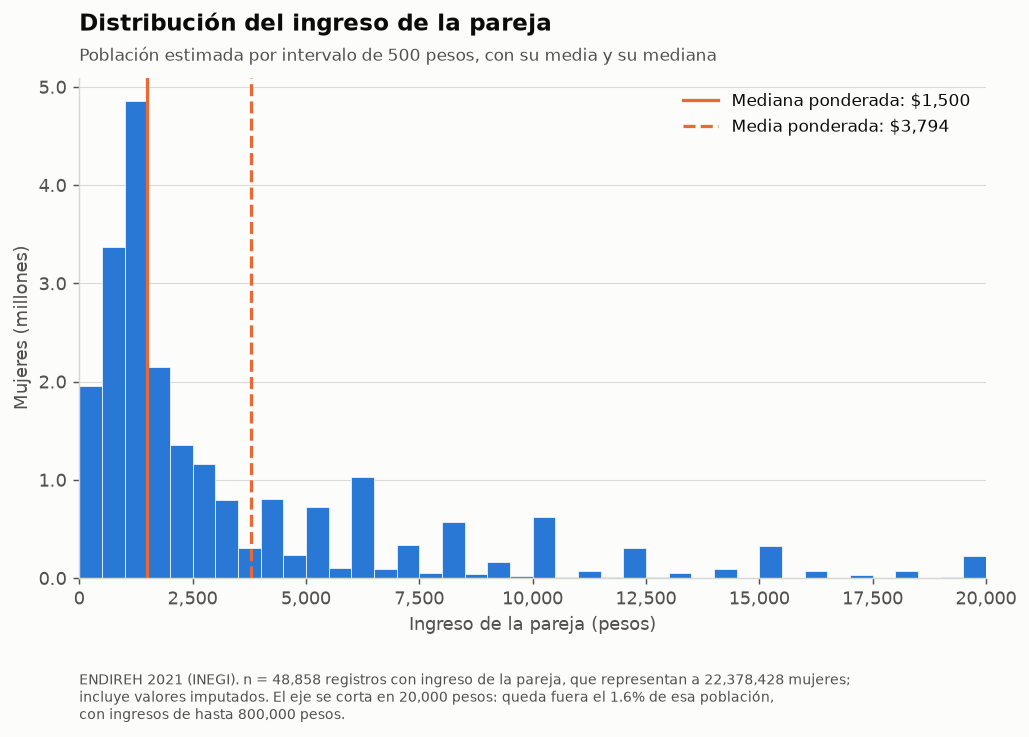

In [3]:
figura_06_distribucion_ingreso(df)
display(Image(filename=str(RUTA_FIGURAS / "06_distribucion_ingreso_pareja.png")))

**Interpretación.** La población se concentra en los ingresos bajos y la cola se extiende hacia la derecha; la media queda en una zona con pocas mujeres, lo que muestra el efecto de los ingresos altos sobre el promedio. Los picos en montos cerrados, como 5,000, 10,000 o 15,000 pesos, sugieren que los ingresos se declaran redondeados.

### 3.3 Variables de significado no confirmado

In [4]:
seccion_localizacion(df, ["edad_primer_union", "num_hijos"])


 MEDIDAS DE LOCALIZACIÓN

La media ponderada usa factor_expansion. La mediana, los cuartiles y
los percentiles ponderados se calculan con una función propia, porque
ni polars ni numpy ofrecen cuantiles con pesos.

--- edad_primer_union
    n = 23,662 observaciones | población estimada = 11,084,038 mujeres
    [!] AVISO: 14,239 valores (60.2%) son menores a 10. Una edad a la primera unión no puede serlo.

    Medida         Sin ponderar      Ponderada
    ------------------------------------------
    Media                 10.03           9.70
    Mediana (Q2)           6.00           6.00
    Moda                   0.00           0.00
    Q1                     2.00           2.00
    Q3                    15.00          15.00
    P10                    0.00           0.00
    P90                   25.00          25.00

    Diferencia media ponderada - media simple: -0.33

--- num_hijos
    n = 86,521 observaciones | población estimada = 36,688,742 mujeres
    [!] AVISO: solo toma 4 v

Los avisos del código muestran que estas variables no se comportan como su nombre indica, y el archivo no trae un diccionario que permita confirmar qué miden; por eso no se interpretan.

## 4. Conclusión

La mediana ponderada del ingreso de la pareja es de 1,500 pesos y la media ponderada de 3,794.10. Por el sesgo a la derecha, la mediana es la medida que describe el caso típico.